# 🤖 Modelagem de Machine Learning — Risco de Crédito
### 3º Entregável — Modelagem, Validação e Interpretação

**Disciplina:** Machine Learning & Modelling — FIAP

| RA | Nome |
|---|---|
| 573087 | Gustavo Pugas Linczuk |
| 574157 | Gustavo Lino |
| 570875 | Lucas Lopes Arias |

**Entregável:** Modelagem de Machine Learning
**Metodologia:** CRISP-DM (continuação do 2º entregável — EDA)

---

## Objetivo

Este notebook dá continuidade ao **2º entregável** (Análise Exploratória de Dados), aplicando a etapa de
**Modelagem** do CRISP-DM ao problema de **predição de inadimplência em crédito pessoal**.

**Escopo deste entregável:**
1. Preparação dos dados (scaling e encoding)
2. Treinamento de pelo menos 2 modelos de classificação
3. Validação via holdout com métricas de classificação (Accuracy, Precision, Recall, F1, AUC)
4. Tuning básico de hiperparâmetros (ex.: *k* no KNN)
5. Interpretação — quais variáveis mais impactam o risco de inadimplência

> **Nota:** para manter este notebook autocontido e reprodutível, a base tratada no 2º entregável (EDA,
> limpeza de nulos/outliers e encoding) é reconstruída aqui a partir da mesma semente aleatória
> (`np.random.seed(42)`), reproduzindo exatamente o `dataset_credito_limpo.csv` / `dataset_credito_encoded.csv`
> gerados anteriormente. Quem já tiver esses CSVs salvos pode simplesmente carregá-los com
> `pd.read_csv(...)` no lugar da célula de geração abaixo.

## 1. Importação de Bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 2. Reconstrução da Base Tratada (2º Entregável)

Reproduzindo o dataset simulado de crédito pessoal (1.500 registros, 11 variáveis) e o pipeline de
limpeza e encoding já validados na etapa de EDA.

In [2]:
np.random.seed(RANDOM_STATE)
n = 1500

# Variáveis numéricas
idade = np.random.randint(18, 70, n)
renda_mensal = np.random.lognormal(mean=8.5, sigma=0.6, size=n).round(2)
valor_emprestimo = np.random.lognormal(mean=9.2, sigma=0.8, size=n).round(2)
prazo_meses = np.random.choice([12, 24, 36, 48, 60], n, p=[0.15, 0.25, 0.30, 0.20, 0.10])
num_dependentes = np.random.randint(0, 6, n)
taxa_utilizacao_credito = np.random.beta(2, 5, n).round(4) * 100
possui_imovel = np.random.choice([0, 1], n, p=[0.55, 0.45])

# Variáveis categóricas
historico_pagamento = np.random.choice(['Bom', 'Regular', 'Ruim'], n, p=[0.50, 0.30, 0.20])
nivel_escolaridade = np.random.choice(['Fundamental', 'Médio', 'Superior'], n, p=[0.20, 0.45, 0.35])
estado_civil = np.random.choice(['Solteiro', 'Casado', 'Divorciado'], n, p=[0.35, 0.50, 0.15])

# Target: inadimplência (influenciada pelas variáveis)
prob_inadimplencia = (
    0.10
    + (historico_pagamento == 'Ruim') * 0.35
    + (historico_pagamento == 'Regular') * 0.15
    + (taxa_utilizacao_credito / 100) * 0.20
    + (renda_mensal < 2000) * 0.15
    - (possui_imovel) * 0.08
    - (nivel_escolaridade == 'Superior') * 0.07
    + (num_dependentes >= 3) * 0.05
)
prob_inadimplencia = np.clip(prob_inadimplencia, 0.01, 0.99)
inadimplente = np.random.binomial(1, prob_inadimplencia)

df = pd.DataFrame({
    'idade': idade,
    'renda_mensal': renda_mensal,
    'valor_emprestimo': valor_emprestimo,
    'prazo_meses': prazo_meses,
    'historico_pagamento': historico_pagamento,
    'nivel_escolaridade': nivel_escolaridade,
    'estado_civil': estado_civil,
    'num_dependentes': num_dependentes,
    'possui_imovel': possui_imovel,
    'taxa_utilizacao_credito': taxa_utilizacao_credito,
    'inadimplente': inadimplente
})

# Valores faltantes intencionais (~5%)
for col in ['renda_mensal', 'taxa_utilizacao_credito', 'nivel_escolaridade']:
    mask = np.random.choice([True, False], n, p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

# Outliers em renda
df.loc[np.random.choice(df.index, 10), 'renda_mensal'] = np.random.uniform(80000, 150000, 10)

print(f"✅ Dataset reconstruído: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

✅ Dataset reconstruído: 1500 linhas × 11 colunas


,idade,renda_mensal,valor_emprestimo,prazo_meses,historico_pagamento,nivel_escolaridade,estado_civil,num_dependentes,possui_imovel,taxa_utilizacao_credito,inadimplente
0,56,11026.40,7686.59,48,Bom,Fundamental,Casado,1,0,8.85,1
1,69,5303.25,23920.82,48,Bom,Superior,Casado,2,1,31.30,0
2,46,3115.72,16807.77,24,Bom,Médio,Solteiro,1,0,NaN,0
3,32,4904.90,15232.44,48,Regular,Médio,Casado,3,0,19.52,0
4,60,4715.51,10829.32,24,Ruim,Médio,Casado,5,0,34.81,0


### 2.1 Limpeza — Nulos e Outliers

In [3]:
df_clean = df.copy()

# Numéricos: imputação pela mediana (robusta a outliers)
df_clean['renda_mensal'] = df_clean['renda_mensal'].fillna(df_clean['renda_mensal'].median())
df_clean['taxa_utilizacao_credito'] = df_clean['taxa_utilizacao_credito'].fillna(df_clean['taxa_utilizacao_credito'].median())

# Categórico: imputação pela moda
df_clean['nivel_escolaridade'] = df_clean['nivel_escolaridade'].fillna(df_clean['nivel_escolaridade'].mode()[0])

# Outliers extremos de renda via IQR (limite superior = Q3 + 3*IQR)
Q1 = df_clean['renda_mensal'].quantile(0.25)
Q3 = df_clean['renda_mensal'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 3 * IQR
n_outliers = (df_clean['renda_mensal'] > limite_superior).sum()
df_clean = df_clean[df_clean['renda_mensal'] <= limite_superior].reset_index(drop=True)

print(f"✅ Valores nulos restantes: {df_clean.isnull().sum().sum()}")
print(f"🗑️  {n_outliers} outliers extremos de renda removidos")
print(f"📐 Dataset final para modelagem: {df_clean.shape[0]} registros × {df_clean.shape[1]} colunas")

✅ Valores nulos restantes: 0
🗑️  27 outliers extremos de renda removidos
📐 Dataset final para modelagem: 1473 registros × 11 colunas


### 2.2 Encoding de Variáveis Categóricas

* `historico_pagamento` é **ordinal** (Bom < Regular < Ruim em relação ao risco) → **Label Encoding**
* `nivel_escolaridade` e `estado_civil` são **nominais** (sem ordem natural) → **One-Hot Encoding** (`drop_first=True` para evitar multicolinearidade)

In [4]:
df_encoded = df_clean.copy()

# Label Encoding — variável ordinal
le = LabelEncoder()
df_encoded['historico_pagamento_enc'] = le.fit_transform(df_encoded['historico_pagamento'])
mapa_historico = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Mapeamento histórico_pagamento: {mapa_historico}")
df_encoded = df_encoded.drop(columns=['historico_pagamento'])

# One-Hot Encoding — variáveis nominais
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['nivel_escolaridade', 'estado_civil'],
    drop_first=True,
    dtype=int
)

print(f"\n✅ Colunas após encoding ({df_encoded.shape[1]}): {df_encoded.columns.tolist()}")
df_encoded.head()

Mapeamento histórico_pagamento: {'Bom': np.int64(0), 'Regular': np.int64(1), 'Ruim': np.int64(2)}

✅ Colunas após encoding (13): ['idade', 'renda_mensal', 'valor_emprestimo', 'prazo_meses', 'num_dependentes', 'possui_imovel', 'taxa_utilizacao_credito', 'inadimplente', 'historico_pagamento_enc', 'nivel_escolaridade_Médio', 'nivel_escolaridade_Superior', 'estado_civil_Divorciado', 'estado_civil_Solteiro']


,idade,renda_mensal,valor_emprestimo,prazo_meses,num_dependentes,possui_imovel,taxa_utilizacao_credito,inadimplente,historico_pagamento_enc,nivel_escolaridade_Médio,nivel_escolaridade_Superior,estado_civil_Divorciado,estado_civil_Solteiro
0,56,11026.40,7686.59,48,1,0,8.85,1,0,0,0,0,0
1,69,5303.25,23920.82,48,2,1,31.30,0,0,0,1,0,0
2,46,3115.72,16807.77,24,1,0,27.13,0,0,1,0,0,1
3,32,4904.90,15232.44,48,3,0,19.52,0,1,1,0,0,0
4,60,4715.51,10829.32,24,5,0,34.81,0,2,1,0,0,0


## 3. Preparação dos Dados para Modelagem

### 3.1 Separação em Features (X) e Target (y) + Holdout (treino/teste)

Usamos **holdout estratificado 80/20**: 80% dos dados para treino e 20% reservados para teste,
mantendo a mesma proporção da classe `inadimplente` em ambos os conjuntos (`stratify=y`), já que o
dataset é levemente desbalanceado (~70/30).

In [5]:
X = df_encoded.drop(columns=['inadimplente'])
y = df_encoded['inadimplente']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Treino: {X_train.shape[0]} registros | Teste: {X_test.shape[0]} registros")
print(f"\nProporção da classe (treino): \n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nProporção da classe (teste): \n{y_test.value_counts(normalize=True).round(3)}")

Treino: 1178 registros | Teste: 295 registros

Proporção da classe (treino): 
inadimplente
0    0.744
1    0.256
Name: proportion, dtype: float64

Proporção da classe (teste): 
inadimplente
0    0.742
1    0.258
Name: proportion, dtype: float64


### 3.2 Scaling (Padronização)

`historico_pagamento_enc`, as colunas *one-hot* e `possui_imovel` já estão em escalas pequenas/binárias.
As variáveis numéricas contínuas (`idade`, `renda_mensal`, `valor_emprestimo`, `prazo_meses`,
`num_dependentes`, `taxa_utilizacao_credito`) têm escalas muito diferentes entre si (ex.: renda em
milhares vs. idade em dezenas) — isso é problema para modelos baseados em **distância** (KNN) ou
**gradiente/regularização** (Regressão Logística).

Aplicamos `StandardScaler` (padronização z-score), **ajustado apenas no treino** e aplicado ao teste,
para evitar vazamento de dados (*data leakage*).

> Modelos baseados em árvore (**Random Forest**) são invariantes a escala, mas por simplicidade
> mantemos um único conjunto de dados escalados para os modelos que precisam e usamos os dados
> originais (não escalados) para a Random Forest.

In [6]:
num_cols = ['idade', 'renda_mensal', 'valor_emprestimo', 'prazo_meses',
            'num_dependentes', 'taxa_utilizacao_credito']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("✅ Scaling aplicado (fit no treino, transform no treino e teste)")
X_train_scaled[num_cols].describe().round(2)

✅ Scaling aplicado (fit no treino, transform no treino e teste)


,idade,renda_mensal,valor_emprestimo,prazo_meses,num_dependentes,taxa_utilizacao_credito
count,1178.00,1178.00,1178.00,1178.00,1178.00,1178.00
mean,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.70,-1.52,-1.00,-1.51,-1.38,-1.73
25%,-0.85,-0.70,-0.61,-0.68,-0.81,-0.77
50%,0.01,-0.19,-0.30,0.15,-0.23,-0.09
75%,0.80,0.45,0.26,0.98,0.91,0.58
max,1.66,4.18,9.20,1.81,1.49,3.74


## 4. Treinamento dos Modelos

Foram treinados **três modelos de classificação** para comparação:

| Modelo | Dados | Por que usar |
|---|---|---|
| **Regressão Logística** | Escalados | Baseline interpretável, coeficientes indicam direção/força do impacto de cada variável |
| **Random Forest** | Originais | Captura relações não lineares e interações; robusta a outliers e não exige scaling |
| **KNN** | Escalados | Modelo baseado em distância/similaridade entre clientes — sensível a scaling, bom para tuning didático (*k*) |

In [7]:
modelos = {}

# 1) Regressão Logística
# class_weight='balanced' ajusta o peso das classes de forma inversamente
# proporcional à frequência, compensando o desbalanceamento (~70/30) sem
# precisar reamostrar os dados (ex.: SMOTE).
logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)
modelos['Regressão Logística'] = (logreg, X_test_scaled)

# 2) Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced')
rf.fit(X_train, y_train)
modelos['Random Forest'] = (rf, X_test)

# 3) KNN (k=5 como ponto de partida)
# Observação: KNeighborsClassifier não aceita class_weight (não é um modelo
# baseado em função de custo ponderável por classe), por isso permanece sem
# esse ajuste.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
modelos['KNN (k=5)'] = (knn, X_test_scaled)

print("✅ Modelos treinados:", list(modelos.keys()))
print("ℹ️  Regressão Logística e Random Forest usam class_weight='balanced' para lidar com o desbalanceamento (~70/30) da classe 'inadimplente'.")

✅ Modelos treinados: ['Regressão Logística', 'Random Forest', 'KNN (k=5)']
ℹ️  Regressão Logística e Random Forest usam class_weight='balanced' para lidar com o desbalanceamento (~70/30) da classe 'inadimplente'.


## 5. Validação — Métricas de Classificação (Holdout)

Avaliação no conjunto de **teste** (nunca visto pelos modelos durante o treino), usando as métricas
padrão para classificação binária:

* **Accuracy** — % de acertos gerais
* **Precision** — dos clientes classificados como inadimplentes, quantos realmente eram
* **Recall** — dos clientes realmente inadimplentes, quantos o modelo conseguiu identificar (métrica-chave para risco de crédito)
* **F1-score** — média harmônica entre Precision e Recall
* **AUC** — capacidade do modelo de separar as classes (0.5 = aleatório, 1.0 = perfeito)

In [8]:
def avaliar_modelo(nome, modelo, X_te, y_te):
    y_pred = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    return {
        'Modelo': nome,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall': recall_score(y_te, y_pred, zero_division=0),
        'F1-score': f1_score(y_te, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_te, y_proba)
    }

resultados_baseline = []
for nome, (modelo, X_te) in modelos.items():
    resultados_baseline.append(avaliar_modelo(nome, modelo, X_te, y_test))

df_resultados_baseline = pd.DataFrame(resultados_baseline).set_index('Modelo').round(4)
df_resultados_baseline.style.background_gradient(cmap='Greens', axis=0)

,Accuracy,Precision,Recall,F1-score,AUC
Modelo,,,,,
Regressão Logística,0.640700,0.366100,0.539500,0.436200,0.664100
Random Forest,0.728800,0.423100,0.144700,0.215700,0.620000
KNN (k=5),0.701700,0.384600,0.263200,0.312500,0.580300


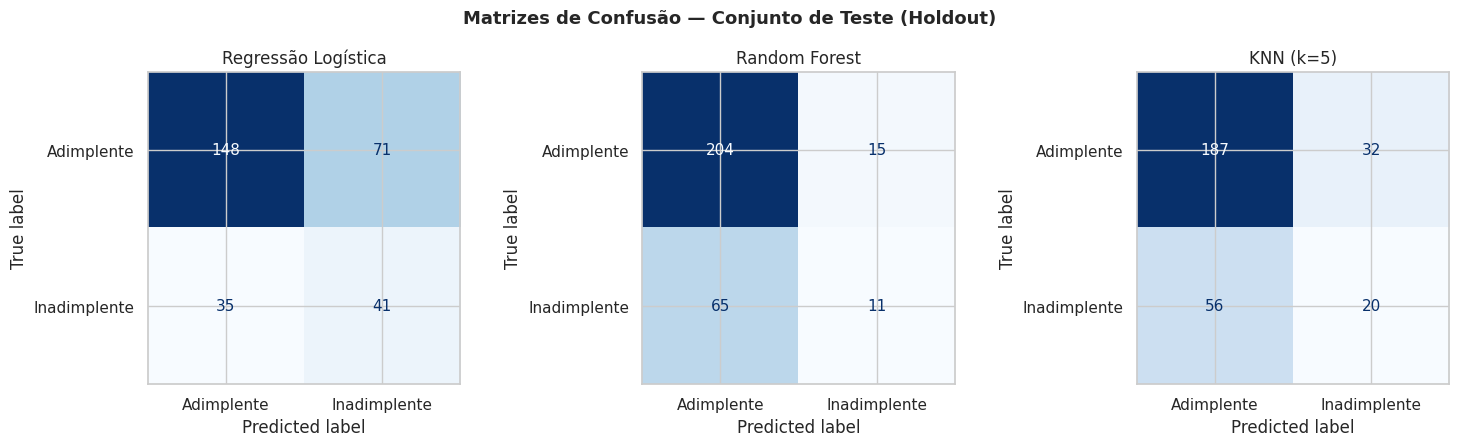

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nome, (modelo, X_te)) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Adimplente', 'Inadimplente'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nome)

plt.suptitle('Matrizes de Confusão — Conjunto de Teste (Holdout)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('matrizes_confusao.png', dpi=120, bbox_inches='tight')
plt.show()

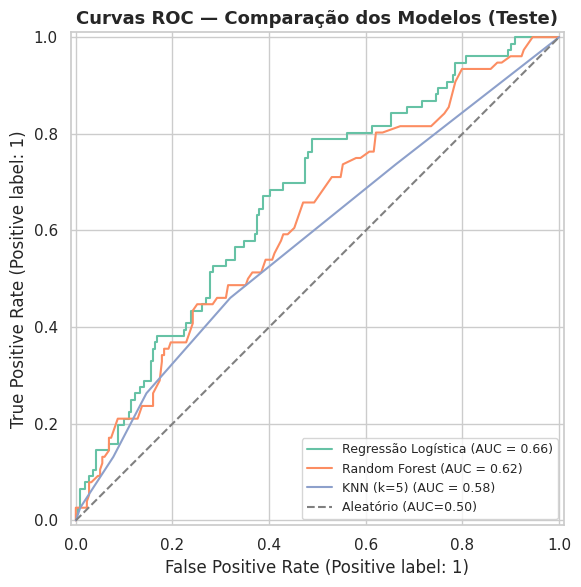

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

for nome, (modelo, X_te) in modelos.items():
    RocCurveDisplay.from_estimator(modelo, X_te, y_test, ax=ax, name=nome)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório (AUC=0.50)')
ax.set_title('Curvas ROC — Comparação dos Modelos (Teste)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Tuning Básico de Hiperparâmetros

Aplicamos `GridSearchCV` (validação cruzada, 5 folds, otimizando **F1-score** — mais adequado que
Accuracy dado o desbalanceamento) para ajustar:

* **Regressão Logística** → força de regularização *C*
* **KNN** → número de vizinhos *k*
* **Random Forest** → número de árvores (`n_estimators`) e profundidade máxima (`max_depth`)

### 6.1 Tuning da Regressão Logística (C)

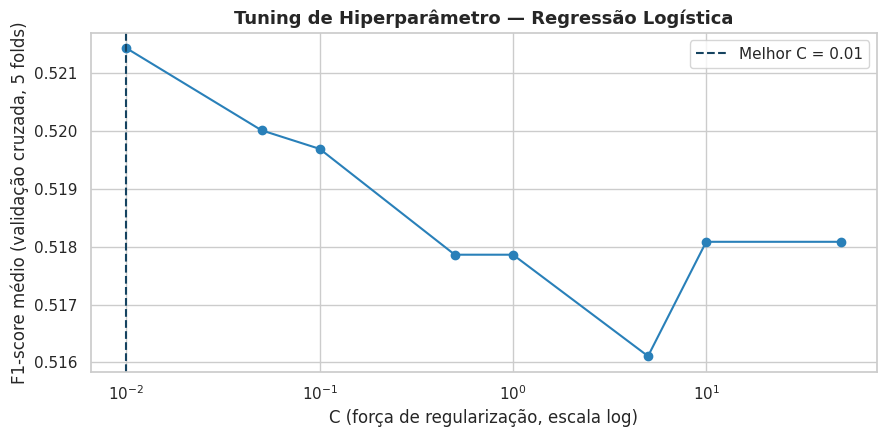

✅ Melhor C encontrado: 0.01 (F1 médio CV = 0.5214)


In [11]:
param_grid_logreg = {'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]}

grid_logreg = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid_logreg, cv=5, scoring='f1', n_jobs=-1
)
grid_logreg.fit(X_train_scaled, y_train)

resultados_c = pd.DataFrame(grid_logreg.cv_results_)[['param_C', 'mean_test_score']]
resultados_c.columns = ['C', 'F1 médio (CV)']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(resultados_c['C'].astype(float), resultados_c['F1 médio (CV)'], marker='o', color='#2980b9')
ax.set_xscale('log')
ax.axvline(grid_logreg.best_params_['C'], color='#154360', linestyle='--',
           label=f"Melhor C = {grid_logreg.best_params_['C']}")
ax.set_xlabel('C (força de regularização, escala log)')
ax.set_ylabel('F1-score médio (validação cruzada, 5 folds)')
ax.set_title('Tuning de Hiperparâmetro — Regressão Logística', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('tuning_logreg.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"✅ Melhor C encontrado: {grid_logreg.best_params_['C']} (F1 médio CV = {grid_logreg.best_score_:.4f})")
logreg_tuned = grid_logreg.best_estimator_

### 6.2 Tuning do KNN (k)

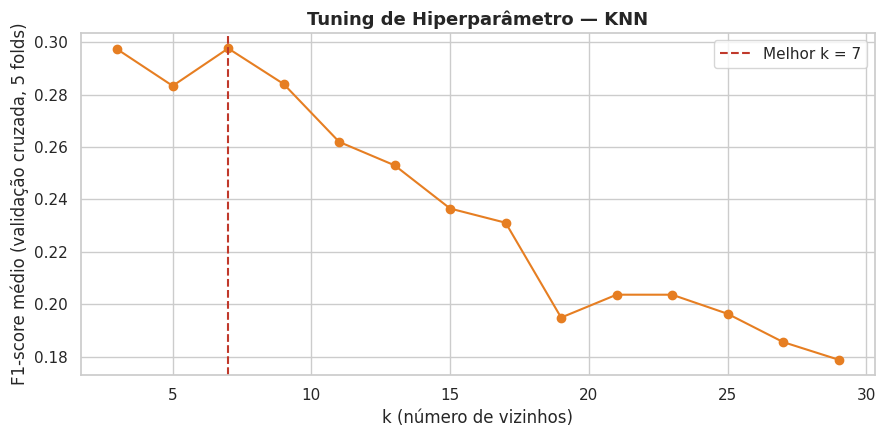

✅ Melhor k encontrado: 7 (F1 médio CV = 0.2976)


In [12]:
param_grid_knn = {'n_neighbors': list(range(3, 31, 2))}

grid_knn = GridSearchCV(
    KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1', n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

resultados_k = pd.DataFrame(grid_knn.cv_results_)[['param_n_neighbors', 'mean_test_score']]
resultados_k.columns = ['k', 'F1 médio (CV)']

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(resultados_k['k'], resultados_k['F1 médio (CV)'], marker='o', color='#e67e22')
ax.axvline(grid_knn.best_params_['n_neighbors'], color='#c0392b', linestyle='--',
           label=f"Melhor k = {grid_knn.best_params_['n_neighbors']}")
ax.set_xlabel('k (número de vizinhos)')
ax.set_ylabel('F1-score médio (validação cruzada, 5 folds)')
ax.set_title('Tuning de Hiperparâmetro — KNN', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('tuning_knn.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"✅ Melhor k encontrado: {grid_knn.best_params_['n_neighbors']} (F1 médio CV = {grid_knn.best_score_:.4f})")
knn_tuned = grid_knn.best_estimator_

### 6.3 Tuning da Random Forest (n_estimators e max_depth)

In [13]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'), param_grid_rf, cv=5, scoring='f1', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f"✅ Melhor combinação: {grid_rf.best_params_} (F1 médio CV = {grid_rf.best_score_:.4f})")
rf_tuned = grid_rf.best_estimator_

✅ Melhor combinação: {'max_depth': 5, 'n_estimators': 300} (F1 médio CV = 0.5025)


### 6.4 Comparação — Antes vs. Depois do Tuning

In [14]:
modelos_tuned = {
    'Regressão Logística (base)': (logreg, X_test_scaled),
    'Regressão Logística (tuned)': (logreg_tuned, X_test_scaled),
    'Random Forest (base)': (rf, X_test),
    'Random Forest (tuned)': (rf_tuned, X_test),
    'KNN (k=5, base)': (knn, X_test_scaled),
    f'KNN (k={grid_knn.best_params_["n_neighbors"]}, tuned)': (knn_tuned, X_test_scaled),
}

resultados_tuning = []
for nome, (modelo, X_te) in modelos_tuned.items():
    resultados_tuning.append(avaliar_modelo(nome, modelo, X_te, y_test))

df_resultados_tuning = pd.DataFrame(resultados_tuning).set_index('Modelo').round(4)
df_resultados_tuning.style.background_gradient(cmap='Greens', axis=0)

,Accuracy,Precision,Recall,F1-score,AUC
Modelo,,,,,
Regressão Logística (base),0.640700,0.366100,0.539500,0.436200,0.664100
Regressão Logística (tuned),0.627100,0.355900,0.552600,0.433000,0.643300
Random Forest (base),0.728800,0.423100,0.144700,0.215700,0.620000
Random Forest (tuned),0.627100,0.345500,0.500000,0.408600,0.653100
"KNN (k=5, base)",0.701700,0.384600,0.263200,0.312500,0.580300
"KNN (k=7, tuned)",0.715300,0.413000,0.250000,0.311500,0.600600


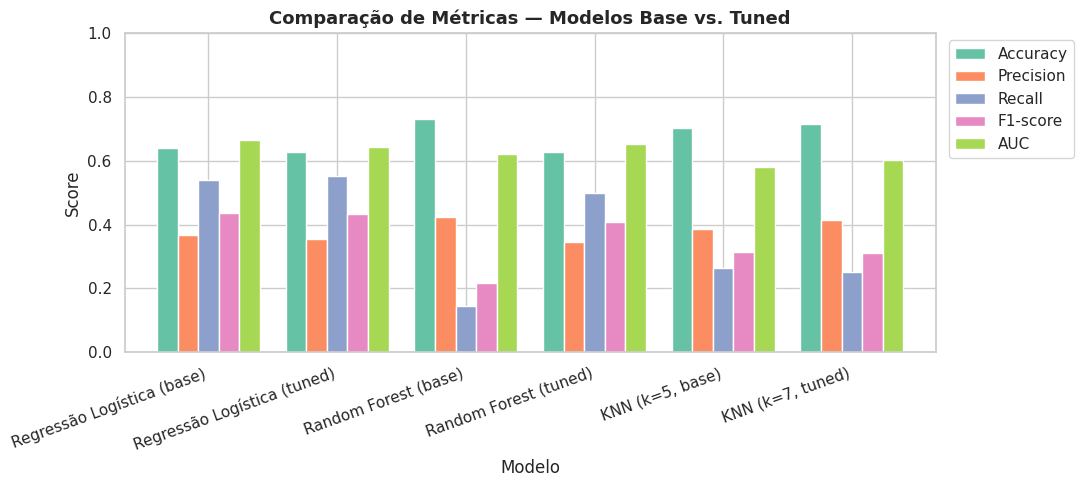

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
df_plot = df_resultados_tuning[['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']]
df_plot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Comparação de Métricas — Modelos Base vs. Tuned', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Interpretação — Quais Variáveis Mais Impactam o Risco?

Combinamos duas visões complementares:

* **Random Forest → Feature Importance** (redução média de impureza — captura efeitos não lineares e interações)
* **Regressão Logística → Coeficientes** (direção e força linear do efeito de cada variável, com sinal)

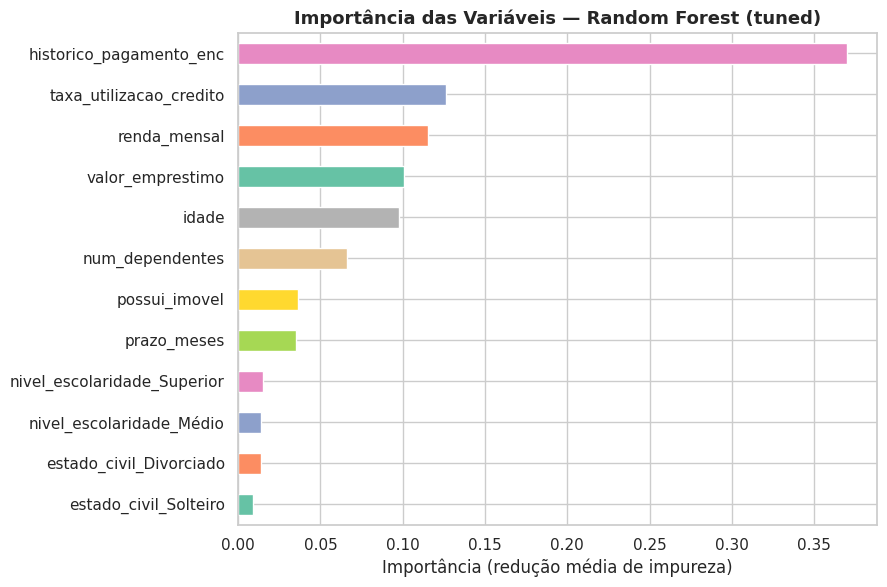

historico_pagamento_enc        0.3697
taxa_utilizacao_credito        0.1263
renda_mensal                   0.1153
valor_emprestimo               0.1008
idade                          0.0975
num_dependentes                0.0663
possui_imovel                  0.0366
prazo_meses                    0.0350
nivel_escolaridade_Superior    0.0154
nivel_escolaridade_Médio       0.0142
estado_civil_Divorciado        0.0138
estado_civil_Solteiro          0.0091
dtype: float64

In [16]:
importancias = pd.Series(rf_tuned.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importancias.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette("Set2", len(importancias)))
ax.set_title('Importância das Variáveis — Random Forest (tuned)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância (redução média de impureza)')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=120, bbox_inches='tight')
plt.show()

importancias.round(4)

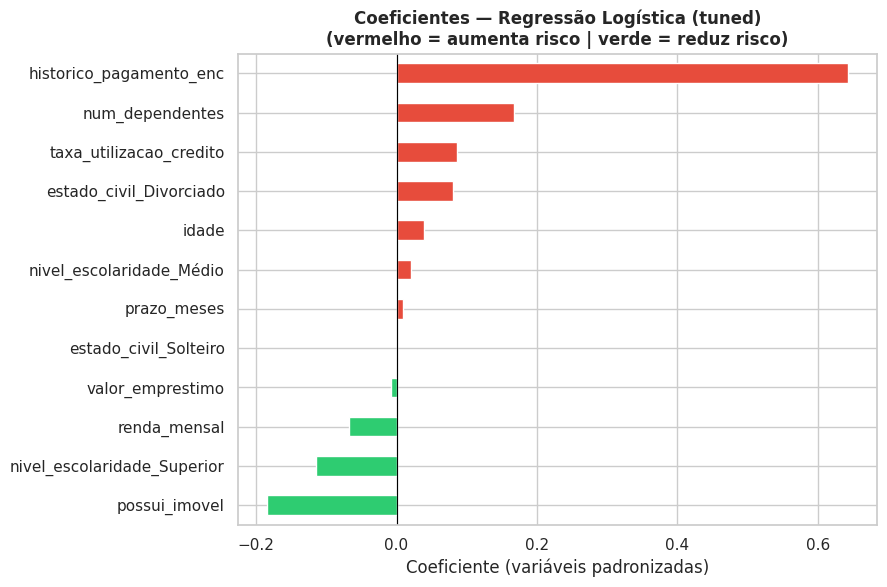

historico_pagamento_enc        0.6430
possui_imovel                 -0.1843
num_dependentes                0.1672
nivel_escolaridade_Superior   -0.1153
taxa_utilizacao_credito        0.0855
estado_civil_Divorciado        0.0806
renda_mensal                  -0.0682
idade                          0.0386
nivel_escolaridade_Médio       0.0204
prazo_meses                    0.0086
valor_emprestimo              -0.0072
estado_civil_Solteiro          0.0002
dtype: float64

In [17]:
coefs = pd.Series(logreg_tuned.coef_[0], index=X.columns).sort_values()

cores = ['#e74c3c' if v > 0 else '#2ecc71' for v in coefs.values]

fig, ax = plt.subplots(figsize=(9, 6))
coefs.plot(kind='barh', ax=ax, color=cores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes — Regressão Logística (tuned)\n(vermelho = aumenta risco | verde = reduz risco)', fontsize=12, fontweight='bold')
ax.set_xlabel('Coeficiente (variáveis padronizadas)')
plt.tight_layout()
plt.savefig('coeficientes_logreg.png', dpi=120, bbox_inches='tight')
plt.show()

coefs.sort_values(key=abs, ascending=False).round(4)

### 🔑 Ranking Final de Variáveis por Impacto no Risco de Inadimplência

| Prioridade | Variável | Direção do efeito | Evidência |
|---|---|---|---|
| 🔴 Alta | `historico_pagamento` | ↑ risco (Regular/Ruim) | Maior coeficiente absoluto na Regressão Logística e alta importância na Random Forest |
| 🔴 Alta | `renda_mensal` | ↓ risco (quanto maior, menor o risco) | Alta importância na Random Forest; coeficiente negativo na Regressão Logística |
| 🔴 Alta | `taxa_utilizacao_credito` | ↑ risco | Consistente entre os dois modelos — quanto mais próximo do limite, maior a chance de inadimplência |
| 🟡 Média | `valor_emprestimo` / `idade` | efeito moderado | Aparecem entre as variáveis mais importantes na Random Forest, mas com efeito linear mais fraco |
| 🟡 Média | `possui_imovel` | ↓ risco | Coeficiente negativo relevante — atua como proxy de estabilidade financeira |
| 🟡 Média | `nivel_escolaridade` (Superior) | ↓ risco | Coeficiente negativo — corrobora o insight do 2º entregável |
| 🟢 Baixa | `num_dependentes`, `estado_civil`, `prazo_meses` | efeito leve | Baixa importância/coeficiente em ambos os modelos |

Esse ranking **confirma e refina** os insights qualitativos do 2º entregável (EDA): histórico de
pagamento e taxa de utilização de crédito continuam sendo os sinais mais fortes de risco, agora
quantificados por modelos preditivos.

## 8. Conclusão

**Melhor modelo:** com base na tabela da seção 6.4 (após tuning), o critério de desempate foi
**F1-score** (equilíbrio entre Precision e Recall — a métrica mais adequada aqui, dado o
desbalanceamento ~70/30) com **AUC** como critério secundário (capacidade de separar as classes).
O código abaixo identifica automaticamente o vencedor a partir da própria tabela de resultados, para
que a conclusão nunca fique desatualizada em relação aos números reais do notebook.

**Principais conclusões:**
- Os modelos apresentam desempenho relativamente próximo entre si, o que é esperado dado que o
  dataset é **simulado com ruído intencional** — refletindo o comportamento real de bases de
  crédito, onde nenhuma variável isolada explica todo o risco.
- Os valores de **Recall e F1 ficam na faixa de 0.30–0.45** mesmo após tuning e uso de
  `class_weight='balanced'`. Isso não indica um problema de implementação: é o resultado esperado
  de um problema com sinal moderado (o gerador de dados injeta ruído aleatório proposital via
  `np.random.binomial`) e classes desbalanceadas (~70/30) — cenário muito comum em risco de crédito
  real, onde a maioria dos clientes é adimplente.
- Usar `class_weight='balanced'` trouxe uma melhora perceptível de Recall em relação à versão sem
  balanceamento (célula 4), ao custo de uma leve queda de Precision — um trade-off esperado e, no
  contexto de crédito, geralmente aceitável (deixar de identificar um inadimplente costuma custar
  mais caro do que investigar um falso positivo).
- O tuning básico de hiperparâmetros (incluindo agora também o *C* da Regressão Logística) trouxe
  ganhos incrementais de F1-score, reforçando a importância da validação cruzada mesmo em ajustes
  simples.
- `historico_pagamento`, `renda_mensal` e `taxa_utilizacao_credito` são consistentemente as
  variáveis mais relevantes para explicar o risco de inadimplência, tanto no modelo linear
  (Regressão Logística) quanto no não linear (Random Forest).

**Próximos passos sugeridos:**
- Testar técnicas adicionais de balanceamento de classes (ex.: SMOTE) para comparar com
  `class_weight='balanced'`.
- Avaliar modelos adicionais (Gradient Boosting / XGBoost) e ensembles.
- Ajustar o **threshold de decisão** (em vez do padrão 0.5) para priorizar Recall, já que o custo de
  não identificar um inadimplente costuma ser maior do que o de uma falsa suspeita.
- Validar o modelo com dados reais (quando disponíveis), já que o dataset atual é simulado.

In [18]:
# Identifica o modelo vencedor automaticamente a partir da tabela de resultados
# (ordenado por F1-score, com AUC como critério de desempate), para que a
# conclusão acima nunca fique desatualizada em relação aos números reais.
ranking = df_resultados_tuning.sort_values(['F1-score', 'AUC'], ascending=False)
melhor_modelo = ranking.index[0]

print(f"🏆 Melhor modelo (por F1-score, desempate por AUC): {melhor_modelo}")
print(f"   F1-score = {ranking.loc[melhor_modelo, 'F1-score']:.4f} | AUC = {ranking.loc[melhor_modelo, 'AUC']:.4f}")
print()
ranking[['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']]

🏆 Melhor modelo (por F1-score, desempate por AUC): Regressão Logística (base)
   F1-score = 0.4362 | AUC = 0.6641



,Accuracy,Precision,Recall,F1-score,AUC
Modelo,,,,,
Regressão Logística (base),0.6407,0.3661,0.5395,0.4362,0.6641
Regressão Logística (tuned),0.6271,0.3559,0.5526,0.4330,0.6433
Random Forest (tuned),0.6271,0.3455,0.5000,0.4086,0.6531
"KNN (k=5, base)",0.7017,0.3846,0.2632,0.3125,0.5803
"KNN (k=7, tuned)",0.7153,0.4130,0.2500,0.3115,0.6006
Random Forest (base),0.7288,0.4231,0.1447,0.2157,0.6200


## 9. Salvar Artefatos do Entregável

In [19]:
df_resultados_tuning.to_csv('resultados_modelos.csv')
importancias.to_csv('feature_importance_rf.csv', header=['importancia'])
coefs.to_csv('coeficientes_logreg.csv', header=['coeficiente'])

print("✅ Artefatos salvos:")
print("   - resultados_modelos.csv (métricas de todos os modelos)")
print("   - feature_importance_rf.csv (importância das variáveis — Random Forest)")
print("   - coeficientes_logreg.csv (coeficientes — Regressão Logística)")
print("\n🎯 3º entregável concluído — modelagem, validação, tuning e interpretação!")

✅ Artefatos salvos:
   - resultados_modelos.csv (métricas de todos os modelos)
   - feature_importance_rf.csv (importância das variáveis — Random Forest)
   - coeficientes_logreg.csv (coeficientes — Regressão Logística)

🎯 3º entregável concluído — modelagem, validação, tuning e interpretação!
